# AFL Match Context Integration

In [242]:
#  Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

In [217]:
# Load the raw datasets
player_performance_data = pd.read_csv('afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv')
team_match_data = pd.read_csv('team_matches_home_away_raw - team_matches_home_away_raw.csv')

In [218]:
# Verify initial dimensions
print("--- Initial Data Shapes ---")
print(f"Players Data Shape: {player_performance_data.shape}")
print(f"Team Match Data Shape: {team_match_data.shape}\n")

--- Initial Data Shapes ---
Players Data Shape: (266640, 36)
Team Match Data Shape: (15808, 19)



## 2. Initial Data Quality Assessment

In [219]:

# Initial Data Quality Assessment

print("--- Missing Values Before Cleaning ---")
print("Player Performance Missing Values:")
print(player_performance_data.isnull().sum())

print("\nTeam Match Missing Values:")
print(team_match_data.isnull().sum())


print("Duplicates in player performance data:", player_performance_data.duplicated().sum())

print("Duplicates in team match data:", team_match_data.duplicated().sum())

--- Missing Values Before Cleaning ---
Player Performance Missing Values:
id                                0
team                              0
year                              0
career_game_count                 0
opponent                          0
round                             0
result                            0
jersey_num                        0
kicks                          1261
marks                          7820
handballs                      4325
disposals                      8042
goals                         72803
behinds                       78946
hit_outs                      94073
tackles                       27939
rebound_50s                   61211
inside_50s                    45418
clearances                    62324
clangers                      48717
free_kicks_for                52449
free_kicks_against            51867
brownlow_votes               107587
contested_possessions         37837
uncontested_possessions       37028
contested_marks           

## 3. Data Cleaning

In [220]:
# 1. Drop the completely empty 'score' column
# Dropped score because it contains 100% missing values and provides no usable information.
player_performance_data = player_performance_data.drop(columns=['score'])

# 2. Drop the corrupted row(s) missing the critical match_date key
player_performance_data = player_performance_data.dropna(subset=['match_date'])

# 3. Fill remaining missing statistical data with zeros
numeric_cols = player_performance_data.select_dtypes(include='number').columns
player_performance_data[numeric_cols] = player_performance_data[numeric_cols].fillna(0)

# 5. Drop the diplicate rows
player_performance_data = player_performance_data.drop_duplicates()

In [221]:
#  Final Validation

print("--- Missing Values After Cleaning ---")
print("Player Performance Missing Values:")
print(player_performance_data.isnull().sum())

print("\nTeam Match Missing Values:")
print(team_match_data.isnull().sum())

print("\n--- Duplicates After Cleaning ---")
print("Duplicates in player performance data:", player_performance_data.duplicated().sum())

# Verify dimensions after cleaning
print("--- After Cleaning Data Shapes ---")
print(f"Players Data Shape: {player_performance_data.shape}")
print(f"Team Match Data Shape: {team_match_data.shape}\n")


--- Missing Values After Cleaning ---
Player Performance Missing Values:
id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                 

In [222]:
#  Data Preview

print("--- Cleaned Data Preview ---")

display(player_performance_data.head(2))
display(team_match_data.head(2))

--- Cleaned Data Preview ---


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,45552.0,1994-08-14,36.0,28.0
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,0.0,...,0.0,0.0,1.0,0.0,0.0,26.0,44356.0,2024-03-16,23.0,8.0


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13


In [223]:
# Rename 'team_name' to 'team'
team_match_data = team_match_data.rename(columns={'team_name': 'team'})

# Standardize text
def clean_strings(df, cols):
    for c in cols:
        df[c] = (
            df[c]
            .astype(str)
            .str.replace(r'\s+', ' ', regex=True)   # removes extra spaces/newlines/tabs
            .str.strip()
            .str.title()
        )
    return df

player_performance_data = clean_strings(
    player_performance_data,
    ['team', 'opponent']
)

team_match_data = clean_strings(
    team_match_data,
    ['team', 'opponent', 'venue']
)

# Fix known naming mismatch
team_match_data['team'] = team_match_data['team'].replace(
    {'W. Bulldogs': 'Western Bulldogs'}
)
team_match_data['opponent'] = team_match_data['opponent'].replace(
    {'W. Bulldogs': 'Western Bulldogs'}
)

## 5. Relationship Discovery

### Common Fields Between Datasets

In [224]:
common_columns = sorted(
    set(player_performance_data.columns)
    .intersection(set(team_match_data.columns))
)

print("\nCommon Columns:")
print(common_columns)


Common Columns:
['id', 'margin', 'match_date', 'opponent', 'result', 'round', 'team', 'year']


Relationship Discovery

Both datasets share several common fields, including team, match_date, opponent, round, year, result, and margin. Although an id column exists in both datasets, it represents different entities (player records and team match records) and therefore cannot be used as a merge key. These shared fields were evaluated to determine the most appropriate merge keys for integrating the datasets.

### Unique Value Assessment

In [225]:
# Check potential merge keys
candidate_keys = [
    'team',
    'match_date',
    'opponent',
    'round',
    'year',
    'result',
    'margin'
]

print("\nUnique Value Counts")
print("-" * 60)

for col in candidate_keys:
    print(f"{col}")
    print(f" Player Dataset : {player_performance_data[col].nunique()}")
    print(f" Team Dataset   : {team_match_data[col].nunique()}")
    print()


Unique Value Counts
------------------------------------------------------------
team
 Player Dataset : 20
 Team Dataset   : 20

match_date
 Player Dataset : 3275
 Team Dataset   : 3347

opponent
 Player Dataset : 20
 Team Dataset   : 20

round
 Player Dataset : 30
 Team Dataset   : 30

year
 Player Dataset : 43
 Team Dataset   : 43

result
 Player Dataset : 3
 Team Dataset   : 3

margin
 Player Dataset : 303
 Team Dataset   : 307



Unique Value Assessment

The two datasets contain the same number of unique teams, opponents, rounds, years, and match results, indicating similar competition coverage. However, the Team Match dataset contains more unique match dates (3347 vs. 3275) and slightly more unique margin values (307 vs. 303), suggesting that the datasets are not perfectly identical. Since unique value counts alone cannot determine whether a field uniquely identifies a match, duplicate analysis was performed in the next step.

### Single Key Evaluation

In [227]:
#  Verify that no single column can uniquely identify a match

print("CHECKING SINGLE KEY UNIQUENESS\n")

for key in candidate_keys:

    player_duplicates = player_performance_data.duplicated(subset=[key]).sum()
    team_duplicates = team_match_data.duplicated(subset=[key]).sum()

    print(f"{key}")
    print(f" Player Dataset Duplicate Values : {player_duplicates}")
    print(f" Team Dataset Duplicate Values   : {team_duplicates}")
    print()

CHECKING SINGLE KEY UNIQUENESS

team
 Player Dataset Duplicate Values : 266609
 Team Dataset Duplicate Values   : 15788

match_date
 Player Dataset Duplicate Values : 263354
 Team Dataset Duplicate Values   : 12461

opponent
 Player Dataset Duplicate Values : 266609
 Team Dataset Duplicate Values   : 15788

round
 Player Dataset Duplicate Values : 266599
 Team Dataset Duplicate Values   : 15778

year
 Player Dataset Duplicate Values : 266586
 Team Dataset Duplicate Values   : 15765

result
 Player Dataset Duplicate Values : 266626
 Team Dataset Duplicate Values   : 15805

margin
 Player Dataset Duplicate Values : 266326
 Team Dataset Duplicate Values   : 15501



No single column could uniquely identify a match because every candidate merge key (team, match_date, opponent, round, year, result, and margin) contained duplicate values in both datasets. As a result, using any single field as the merge key could produce incorrect or ambiguous matches. Therefore, a composite key was required to accurately link player records with their corresponding team match records.

### Composite Key Evaluation

In [230]:
#  Check the candidate composite key
merge_keys = ['team', 'match_date', 'opponent']

print("CHECKING COMPOSITE KEY")

team_duplicate_keys = team_match_data.duplicated(
    subset=merge_keys
).sum()

print(f"Duplicate composite keys in Team Match dataset: {team_duplicate_keys}")

CHECKING COMPOSITE KEY
Duplicate composite keys in Team Match dataset: 0


Composite Key Evaluation

Individual columns such as team, match_date, and opponent were not unique and therefore could not be used independently for merging. The composite key consisting of team, match_date, and opponent produced zero duplicate combinations in the Team Match dataset, confirming that it uniquely identifies records in that dataset. This made it suitable for performing a many-to-one merge with the player performance data.

### Relationship Type

In [232]:
# Determine the relationship between datasets

merge_keys = ['team', 'match_date', 'opponent']

print("RELATIONSHIP TYPE\n")

player_records = (
    player_performance_data
    .groupby(merge_keys)
    .size()
)

team_records = (
    team_match_data
    .groupby(merge_keys)
    .size()
)


print("Player records per match")
print(player_records.describe())

print("\nTeam records per match")
print(team_records.describe())

RELATIONSHIP TYPE

Player records per match
count    14691.000000
mean        18.149139
std          6.793513
min          1.000000
25%         18.000000
50%         21.000000
75%         22.000000
max         26.000000
dtype: float64

Team records per match
count    15808.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64


In [233]:
print(f"Average player records per match: {player_records.mean():.2f}")
print(f"Maximum player records in a match: {player_records.max()}")
print(f"Average team match records per match: {team_records.mean():.2f}")

Average player records per match: 18.15
Maximum player records in a match: 26
Average team match records per match: 1.00


## 6. Context Enrichment

In [234]:
#  Context Enrichment (The Merge)

# Define the composite key required to accurately match games
merge_keys = ['team', 'match_date', 'opponent']

# Specify the new match context columns we want to add
cols_to_bring_in = merge_keys + ['home_away', 'venue', 'crowd']

# Execute the left merge
enriched_afl_data = player_performance_data.merge(
    team_match_data[cols_to_bring_in],
    on=merge_keys,
    how='left',
    validate='many_to_one',
    indicator=True
)

## 7. Merge Validation

### Record Count Validation

In [235]:
#  Record count validation
print(f"Original Player Records : {len(player_performance_data)}")
print(f"Merged Player Records   : {len(enriched_afl_data)}")

if len(player_performance_data) == len(enriched_afl_data):
    print(" Record count preserved.")
else:
    print(" Record count changed.")


Original Player Records : 266629
Merged Player Records   : 266629
 Record count preserved.


### Merge Indicator Summary

In [236]:
# Merge indicator check
print("\nMerge Indicator Summary")
print(enriched_afl_data['_merge'].value_counts())



Merge Indicator Summary
_merge
both          266629
left_only          0
right_only         0
Name: count, dtype: int64


### Unmatched Records

In [237]:
# Unmatched records
unmatched = enriched_afl_data[enriched_afl_data['_merge'] == 'left_only']

print(f"\nUnmatched Records: {len(unmatched)}")

if len(unmatched) > 0:
    display(unmatched[['team', 'match_date', 'opponent']].head())


Unmatched Records: 0


### Duplicate Record Check

In [238]:
# Check duplicate player records after merge
duplicate_rows = enriched_afl_data.duplicated().sum()

print(f"\nDuplicate Rows After Merge: {duplicate_rows}")

# Remove merge indicator after validation
enriched_afl_data = enriched_afl_data.drop(columns=['_merge'])



Duplicate Rows After Merge: 0


## 8. Contextual Analysis

### Home vs Away Performance

In [239]:
# Home vs Away Performance
home_away_stats = enriched_afl_data.groupby('home_away')['fantasy_points'].mean().round(2)
print(f"Average Fantasy Points (Home - H): {home_away_stats.get('H', 0)}")
print(f"Average Fantasy Points (Away - A): {home_away_stats.get('A', 0)}")
if home_away_stats.get('H', 0) > home_away_stats.get('A', 0):
    print("Conclusion: Players generally perform better at home.\n")
elif home_away_stats.get('H', 0) < home_away_stats.get('A', 0):
    print("Conclusion: Players generally perform better away from home.\n")
else:
    print("Conclusion: Players perform similarly at home and away.\n")

Average Fantasy Points (Home - H): 66.47
Average Fantasy Points (Away - A): 64.0
Conclusion: Players generally perform better at home.



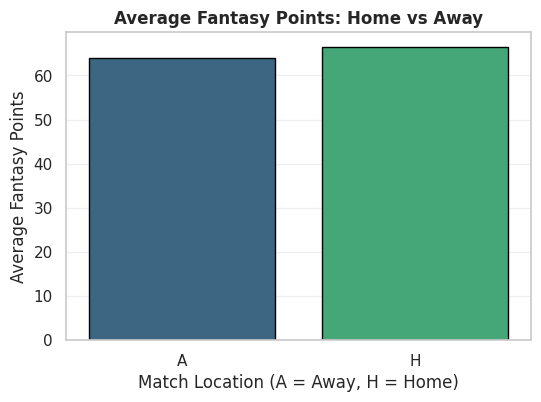

In [261]:
# Create the figure
plt.figure(figsize=(6, 4))

# Use seaborn for the bar plot
sns.barplot(
    x=home_away_stats.index,
    y=home_away_stats.values,
    hue=home_away_stats.index,  # Assign hue to avoid Seaborn warnings
    palette='viridis',           # Gives it a clean, modern color scheme
    edgecolor='black'
)

# Add titles and labels
plt.title('Average Fantasy Points: Home vs Away', fontweight='bold')
plt.xlabel('Match Location (A = Away, H = Home)')
plt.ylabel('Average Fantasy Points')

# Add a subtle grid
plt.grid(axis='y', alpha=0.3)
plt.savefig('charts/home_vs_away.png', dpi=100 )
plt.show()

### Crowd Size vs Fantasy Points

In [240]:
# Crowd Influence on Fantasy Points
# Calculate the Pearson correlation coefficient
crowd_corr = enriched_afl_data[['crowd', 'fantasy_points']].corr().iloc[0, 1]
print(f"Correlation between Crowd Size and Fantasy Points: {crowd_corr:.4f}")
if abs(crowd_corr) < 0.1:
    print("Conclusion: Crowd size shows little or no relationship with fantasy points.\n")
elif abs(crowd_corr) < 0.3:
    print("Conclusion: Crowd size shows a weak relationship with fantasy points.\n")
elif abs(crowd_corr) < 0.5:
    print("Conclusion: Crowd size shows a moderate relationship with fantasy points.\n")
else:
    print("Conclusion: Crowd size shows a strong relationship with fantasy points.\n")

Correlation between Crowd Size and Fantasy Points: 0.0130
Conclusion: Crowd size shows little or no relationship with fantasy points.



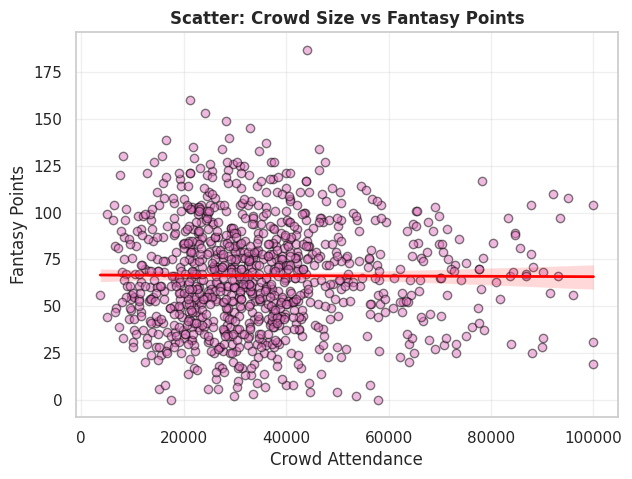

In [ ]:
sample_data = enriched_afl_data[

    ['crowd', 'fantasy_points']

].dropna().sample(1000, random_state=42)


plt.figure(figsize=(7, 5))

# sns.regplot plots the scatter points AND calculates/draws the regression line automatically
sns.regplot(
    data=sample_data,
    x='crowd',
    y='fantasy_points',
    scatter_kws={'alpha': 0.5, 'color': '#e377c2', 'edgecolor': 'black'}, # Styling the dots
    line_kws={'color': 'red', 'linewidth': 2}                           # Styling the trendline
)

plt.title('Scatter: Crowd Size vs Fantasy Points', fontweight='bold')
plt.xlabel('Crowd Attendance')
plt.ylabel('Fantasy Points')

plt.grid(alpha=0.3)
plt.savefig('charts/crowd_size_vs_fantasy_points.png', dpi=100 )
plt.show()

### Top Performing Venues

In [244]:
# Top Venues for Player Performance
# Group by venue and calculate both mean points and total matches played
venue_stats = enriched_afl_data.groupby('venue').agg(
    avg_fantasy_points=('fantasy_points', 'mean'),
    player_matches=('fantasy_points', 'count')
).reset_index()

# Filter out venues with very few records (< 1000) to ensure statistical significance
top_venues = venue_stats[venue_stats['player_matches'] > 1000].sort_values(
    by='avg_fantasy_points', ascending=False
).head(5)

print("--- Top 5 Venues by Average Player Performance ---")
# Displaying cleanly as a dataframe
print(top_venues.round(2))

--- Top 5 Venues by Average Player Performance ---
             venue  avg_fantasy_points  player_matches
30    Utas Stadium               68.03            4225
10   Engie Stadium               67.81            4878
17  Marvel Stadium               67.54           50482
3    Adelaide Oval               67.51           12789
28     Tio Stadium               67.17            1281


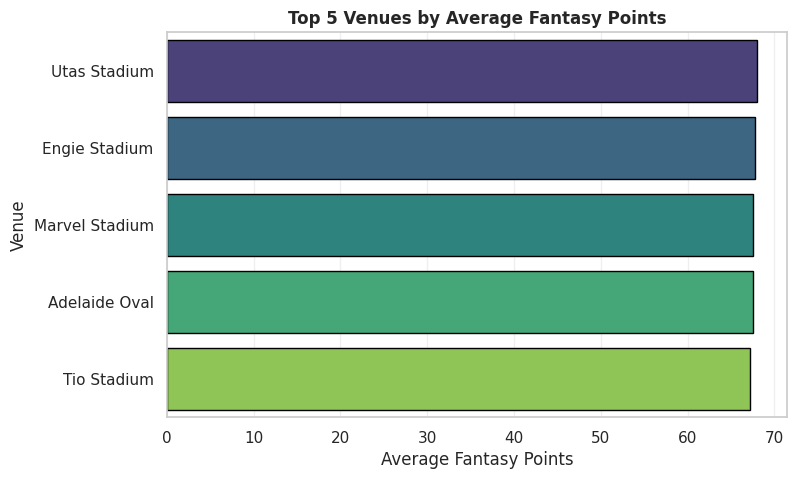

In [262]:
plt.figure(figsize=(8, 5))

# Seaborn automatically handles the horizontal orientation when you put the categorical data on 'y'
sns.barplot(
    data=top_venues,
    x='avg_fantasy_points',
    y='venue',
    hue='venue',           # Assign hue to avoid warnings and enable the palette
    palette='viridis',     # Matches the palette you used in your 2x3 grid
    edgecolor='black'
)

plt.title('Top 5 Venues by Average Fantasy Points', fontweight='bold')
plt.xlabel('Average Fantasy Points')
plt.ylabel('Venue')

plt.grid(axis='x', alpha=0.3)
plt.savefig('charts/top5_venues_by_fantasy_points.png', dpi=100 )
plt.show()

## 9. Data Quality Report

### Merge Keys Used

A composite key consisting of **`team`**, **`match_date`**, and **`opponent`** was used to merge the player performance dataset with the team match dataset. Relationship discovery showed that no single column uniquely identified a match, while this composite key uniquely identified each team match and supported a correct many-to-one merge.

### Challenges Encountered

* Team and opponent names contained inconsistent formatting, requiring standardization before merging.
* The match dataset used the abbreviated team name **"W. Bulldogs"**, whereas the player dataset used **"Western Bulldogs"**. This inconsistency was resolved by mapping the abbreviation to the full team name.
* Venue names contained inconsistent whitespace and newline characters, which were cleaned to ensure consistent grouping during analysis.

### Data Quality Issues Discovered

* The **`score`** column in the player dataset contained 100% missing values and was removed because it provided no useful information.
* One player record had a missing **`match_date`**, which was removed because it was required as part of the composite merge key.
* The **`crowd`** column contained **398 missing values** in the team match dataset.
* Ten duplicate records were identified and removed from the player performance dataset before merging.

### Assumptions Made During Integration

* Missing values in player performance statistics (e.g., kicks, marks, goals, tackles, and hit outs) were assumed to indicate that the player recorded zero for those statistics in the match, so these values were replaced with **0**.
* Missing **`crowd`** values were retained because crowd attendance was not required for the merge. Analyses involving crowd attendance excluded records with missing values. The cause of these missing values could not be determined from the available dataset.